# Phase 2: Lightweight Deep Learning Baseline

This notebook implements the Phase 2 pipeline: **CNN-based regulatory sequence classification** with convolutional filter visualization and nucleotide-resolution attribution maps.

### Phases Covered:
- **Phase 0 (Data)**: Reuses ENCODE K562 dataset curated in Phase 1 (PLS + dELS cCREs, GC-matched negatives).
- **Phase 2**: Shallow CNN and Deep CNN training on one-hot encoded sequences; filter motif extraction; Saliency & Integrated Gradients attributions.
- **Comparison**: Updated model comparison table extending Phase 1 classical baselines with CNN results.

## 1. Environment Setup & Repository Integration

In [1]:
import os
import sys
import subprocess
import importlib
import time
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, log_loss

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# 1. Git pull or clone codebase
repo_dir = "/kaggle/working/interpretable-regulatory-genomics"
if not os.path.exists(repo_dir):
    print("Cloning repository...")
    subprocess.run(["git", "clone", "https://github.com/PxA-Labs/interpretable-regulatory-genomics.git", repo_dir], check=True)
else:
    print("Repository exists. Pulling latest updates...")
    subprocess.run(["git", "-C", repo_dir, "pull"], check=True)

# 2. Add to path
if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)

# 3. Auto-install missing libraries
def install_and_import(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Library '{package_name}' not found. Installing...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package_name], check=True)

install_and_import("xgboost")
install_and_import("shap")
install_and_import("logomaker")
install_and_import("captum")
print("All dependencies verified.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Cloning repository...


Cloning into '/kaggle/working/interpretable-regulatory-genomics'...


Library 'logomaker' not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 97.0 MB/s eta 0:00:00
Library 'captum' not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.0 MB/s eta 0:00:00
All dependencies verified.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 2. Dynamic Package Module Loading

In [2]:
import src
import src.data
import src.data.download
import src.data.parse_encode
import src.data.sequence_extractor
import src.data.negative_sampling
import src.data.dataset
import src.features
import src.features.kmer
import src.models
import src.models.base_model
import src.models.logistic
import src.models.tree_ensemble
import src.models.cnn
import src.models.train_nn
import src.models.registry
import src.interpret
import src.interpret.shap_analysis
import src.interpret.cnn_interpretability

for module in [
    src, src.data, src.data.download, src.data.parse_encode,
    src.data.sequence_extractor, src.data.negative_sampling,
    src.data.dataset, src.features, src.features.kmer,
    src.models, src.models.base_model, src.models.logistic,
    src.models.tree_ensemble, src.models.cnn, src.models.train_nn,
    src.models.registry, src.interpret,
    src.interpret.shap_analysis, src.interpret.cnn_interpretability
]:
    importlib.reload(module)

print("All pipeline modules loaded and reloaded successfully.")

All pipeline modules loaded and reloaded successfully.


## 3. Directory Initialization & Data Source Detection

In [3]:
raw_dir = "/kaggle/working/data/raw"
processed_dir = "/kaggle/working/data/processed"
reference_dir = "/kaggle/working/data/reference"
plot_dir = "/kaggle/working/plots"

for path in [raw_dir, processed_dir, reference_dir, plot_dir]:
    os.makedirs(path, exist_ok=True)

def detect_fasta_source():
    input_base = "/kaggle/input"
    if os.path.exists(input_base):
        for root, dirs, files in os.walk(input_base):
            has_chrom_fasta = any(
                (f.startswith("chr") and (f.endswith(".fa") or f.endswith(".fa.gz") or f.endswith(".fasta") or f.endswith(".fasta.gz")))
                for f in files
            )
            if has_chrom_fasta:
                print(f"Detected mounted reference genome at: {root}")
                return root, False
    print("Mounted hg38 dataset not found. Running in Test mode (using chr19)...")
    return reference_dir, True

fasta_source, is_test_mode = detect_fasta_source()

Mounted hg38 dataset not found. Running in Test mode (using chr19)...


## 4. Data Curation Pipeline

Reuses the same ENCODE K562 cCRE pipeline from Phase 1 (PLS + dELS elements, 1000 bp centered, GC-matched negative sampling).

In [4]:
# A. Download ENCODE cCRE annotations
ccres_raw_path = src.data.download.download_encode_ccres(raw_dir)

if is_test_mode:
    print("Downloading chr19 reference sequence for test execution...")
    src.data.download.download_hg38_chromosome("chr19", reference_dir)
    chromosomes_to_use = ["chr19"]
else:
    chromosomes_to_use = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

# B. Parse and center-resize BED coordinates to 1000 bp
parsed_bed_path = os.path.join(processed_dir, "k562_active_ccres.bed")
src.data.parse_encode.parse_and_resize_ccres(
    input_path=ccres_raw_path,
    output_path=parsed_bed_path,
    element_types=['PLS', 'dELS'],
    target_length=1000,
    chromosomes=chromosomes_to_use
)

Download complete.
Download complete.
Parsing cCRE annotations from /kaggle/working/data/raw/ENCFF726XBE.bed.gz...
Loaded 2348854 initial regions.
Filtered by chromosomes. Remaining: 62004
Filtered by element types ['PLS', 'dELS']. Remaining: 2016
Resizing regions to fixed length of 1000 bp...
Filtered out regions with invalid coordinates. Remaining: 2016
Processed BED file saved to /kaggle/working/data/processed/k562_active_ccres.bed (Total regions: 2016).


'/kaggle/working/data/processed/k562_active_ccres.bed'

## 5. Sequence Extraction & GC-Matched Negative Sampling

In [5]:
# C. Extract sequences for the BED coordinates
extracted_tsv_path = os.path.join(processed_dir, "k562_active_ccres_sequences.tsv")
src.data.sequence_extractor.extract_sequences(
    bed_path=parsed_bed_path,
    fasta_source=fasta_source,
    output_path=extracted_tsv_path,
    max_n_fraction=0.10
)

# D. Sample GC-stratified negative non-coding sequences
combined_dataset_path = os.path.join(processed_dir, "k562_combined_dataset.tsv")
src.data.negative_sampling.build_negative_dataset(
    pos_tsv_path=extracted_tsv_path,
    fasta_source=fasta_source,
    output_path=combined_dataset_path,
    target_length=1000
)

Reading BED coordinates from /kaggle/working/data/processed/k562_active_ccres.bed...
Total input regions: 2,016
Loading chromosome sequence from /kaggle/working/data/reference/chr19.fa.gz...
Loaded sequence of length 58,617,616 bp.
Sequence extraction complete.
  Extracted regions: 2,016
  Skipped (out of bounds): 0
  Skipped (high N-base fraction): 0
Saved extracted sequences to /kaggle/working/data/processed/k562_active_ccres_sequences.tsv.
Loading positive regions with sequences from /kaggle/working/data/processed/k562_active_ccres_sequences.tsv...
Loading chromosome sequence from /kaggle/working/data/reference/chr19.fa.gz...
Loaded sequence of length 58,617,616 bp.
Sampling negatives for chromosome chr19...
Target negative bin counts for chr19: {12: 548, 11: 522, 13: 365, 10: 277, 14: 144, 9: 101, 15: 31, 8: 23, 16: 3, 7: 2}
Sampled 2016 / 2016 negatives for chr19 (attempts: 49073).
Saved combined positive & negative dataset to /kaggle/working/data/processed/k562_combined_dataset.t

'/kaggle/working/data/processed/k562_combined_dataset.tsv'

## 6. Train/Test Partition

In [6]:
print("Loading combined dataset...")
df_dataset = pd.read_csv(combined_dataset_path, sep='\t')
print(f"Total samples: {len(df_dataset):,} (Positives: {df_dataset['label'].sum():,.0f}, Negatives: {(1-df_dataset['label']).sum():,.0f})")

if is_test_mode:
    print("Performing standard 80/20 train/test random split...")
    from sklearn.model_selection import train_test_split
    df_train, df_test = train_test_split(df_dataset, test_size=0.2, random_state=42, stratify=df_dataset['label'])
else:
    print("Applying chromosome-holdout split policy (Full Mode)...")
    train_mask = ~np.isin(df_dataset['chrom'].values, ['chr19', 'chr20', 'chr21', 'chr22'])
    test_mask = (df_dataset['chrom'].values == 'chr19')
    
    if train_mask.sum() == 0 or test_mask.sum() == 0:
        print("Warning: Holdout chromosome(s) not found. Falling back to random split.")
        from sklearn.model_selection import train_test_split
        df_train, df_test = train_test_split(df_dataset, test_size=0.2, random_state=42, stratify=df_dataset['label'])
    else:
        df_train = df_dataset[train_mask].reset_index(drop=True)
        df_test = df_dataset[test_mask].reset_index(drop=True)
        print(f"Chromosome split: Train size = {len(df_train):,}, Test size = {len(df_test):,}")

print(f"Train: {len(df_train):,} samples, Test: {len(df_test):,} samples")

Loading combined dataset...
Total samples: 4,032 (Positives: 2,016, Negatives: 2,016)
Performing standard 80/20 train/test random split...
Train: 3,225 samples, Test: 807 samples


## 7. One-Hot Encoding Dataset Verification

Verify that `GenomicDataset` correctly one-hot encodes sequences and feeds batches to the DataLoader.

In [8]:
from torch.utils.data import DataLoader

train_dataset = src.data.dataset.GenomicDataset(df_train)
test_dataset = src.data.dataset.GenomicDataset(df_test)

print(f"Train dataset size: {len(train_dataset):,}")
print(f"Test dataset size:  {len(test_dataset):,}")

# Verify first sample shape
x_sample, y_sample = train_dataset[0]
print(f"Input tensor shape (one-hot): {x_sample.shape}  (expected: [4, 1000])")
print(f"Label: {y_sample.item():.0f}")

Train dataset size: 3,225
Test dataset size:  807
Input tensor shape (one-hot): torch.Size([4, 1000])  (expected: [4, 1000])
Label: 0


## 8. CNN Model Training

Train **ShallowCNN** and **DeepCNN** models using the `ModelRegistry`. Each model is wrapped in `PyTorchModelWrapper` which handles the train/validation loop, early stopping, and GPU acceleration automatically.

In [9]:
y_train = df_train['label'].values
y_test = df_test['label'].values

cnn_models_to_train = {
    "shallow_cnn": {
        "epochs": 30,
        "batch_size": 64,
        "lr": 0.001,
        "weight_decay": 1e-5,
        "val_split": 0.15,
        "patience": 6,
        "n_filters_1": 64,
        "n_filters_2": 128,
        "kernel_size_1": 15,
        "kernel_size_2": 9,
        "pool_size": 4,
        "dropout_rate": 0.3
    },
    "deep_cnn": {
        "epochs": 30,
        "batch_size": 64,
        "lr": 0.001,
        "weight_decay": 1e-5,
        "val_split": 0.15,
        "patience": 6,
        "dropout_rate": 0.4
    }
}

trained_cnn_models = {}
cnn_metrics_results = []

for name, params in cnn_models_to_train.items():
    print(f"\n{'='*60}")
    print(f"Training: {name.upper()}")
    print('='*60)
    start_time = time.time()
    
    # Get model wrapper from registry
    model = src.models.registry.ModelRegistry.get_model(name, params)
    
    # Fit using sequence strings; GenomicDataset handles one-hot encoding internally
    model.fit(df_train['sequence'].values, y_train)
    elapsed = time.time() - start_time
    
    # Evaluate on test set
    y_prob = model.predict_proba(df_test['sequence'].values)
    y_pred = model.predict(df_test['sequence'].values)
    
    auroc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    loss = log_loss(y_test, y_prob)
    
    cnn_metrics_results.append({
        "Model": name.upper().replace("_", " "),
        "AUROC": auroc,
        "AUPRC": auprc,
        "F1-Score": f1,
        "Log Loss": loss,
        "Train Time (s)": elapsed
    })
    
    trained_cnn_models[name] = model
    print(f"\nTest AUROC: {auroc:.4f} | AUPRC: {auprc:.4f} | F1: {f1:.4f}")

df_cnn_metrics = pd.DataFrame(cnn_metrics_results)
print("\n======== CNN MODEL PERFORMANCE ========")
print(df_cnn_metrics.to_string(index=False))


Training: SHALLOW_CNN
Training on device: cuda
Epoch 01/30 | Train Loss: 0.6987 | Val Loss: 0.6594 | Val Acc: 0.6439
Epoch 02/30 | Train Loss: 0.6467 | Val Loss: 0.6307 | Val Acc: 0.6398
Epoch 03/30 | Train Loss: 0.5859 | Val Loss: 0.5732 | Val Acc: 0.7164
Epoch 04/30 | Train Loss: 0.5388 | Val Loss: 0.5465 | Val Acc: 0.7226
Epoch 05/30 | Train Loss: 0.4736 | Val Loss: 0.4955 | Val Acc: 0.7764
Epoch 06/30 | Train Loss: 0.4406 | Val Loss: 0.4891 | Val Acc: 0.7909
Epoch 07/30 | Train Loss: 0.3999 | Val Loss: 0.4816 | Val Acc: 0.7764
Epoch 08/30 | Train Loss: 0.3643 | Val Loss: 0.4740 | Val Acc: 0.7950
Epoch 09/30 | Train Loss: 0.3630 | Val Loss: 0.5260 | Val Acc: 0.7805
Epoch 10/30 | Train Loss: 0.3269 | Val Loss: 0.4657 | Val Acc: 0.7909
Epoch 11/30 | Train Loss: 0.2846 | Val Loss: 0.4567 | Val Acc: 0.7971
Epoch 12/30 | Train Loss: 0.2687 | Val Loss: 0.4758 | Val Acc: 0.7992
Epoch 13/30 | Train Loss: 0.2636 | Val Loss: 0.4685 | Val Acc: 0.8033
Epoch 14/30 | Train Loss: 0.2279 | Val Los

## 9. Full Model Comparison Table (Phase 1 + Phase 2)

Extend the Phase 1 baseline results with the CNN results to produce a comprehensive comparison.

In [10]:
from src.features.kmer import extract_kmer_features

# Recompute k-mer features for Phase 1 models comparison
X_train_kmer, kmer_names = extract_kmer_features(df_train, k=4)
X_test_kmer, _ = extract_kmer_features(df_test, k=4)

phase1_models_to_train = {
    "logistic_regression": {"max_iter": 1000},
    "random_forest": {"n_estimators": 500, "n_jobs": -1},
    "xgboost": {"n_estimators": 500, "n_jobs": -1, "eval_metric": "logloss"}
}

phase1_metrics_results = []
for name, params in phase1_models_to_train.items():
    start_time = time.time()
    model = src.models.registry.ModelRegistry.get_model(name, params)
    model.fit(X_train_kmer, y_train)
    elapsed = time.time() - start_time
    
    y_prob = model.predict_proba(X_test_kmer)
    y_pred = model.predict(X_test_kmer)
    
    phase1_metrics_results.append({
        "Model": name.upper().replace("_", " "),
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "F1-Score": f1_score(y_test, y_pred),
        "Log Loss": log_loss(y_test, y_prob),
        "Train Time (s)": elapsed
    })

df_all_metrics = pd.concat([pd.DataFrame(phase1_metrics_results), df_cnn_metrics], ignore_index=True)
print("\n============= FULL MODEL COMPARISON: PHASE 1 + PHASE 2 =============")
print(df_all_metrics.to_string(index=False))
print("====================================================================")

Extracting 4-mer features (total features: 256)...
  Processed 1000 / 3225 sequences.
  Processed 2000 / 3225 sequences.
  Processed 3000 / 3225 sequences.
  Processed 3225 / 3225 sequences.
k-mer feature extraction complete.
Extracting 4-mer features (total features: 256)...
  Processed 807 / 807 sequences.
k-mer feature extraction complete.

============= FULL MODEL COMPARISON: PHASE 1 + PHASE 2 =============
              Model    AUROC    AUPRC  F1-Score  Log Loss  Train Time (s)
LOGISTIC REGRESSION 0.778075 0.730084  0.731771  0.659684        0.042915
      RANDOM FOREST 0.863487 0.872212  0.791123  0.485374        3.292949
            XGBOOST 0.894498 0.893204  0.807643  0.579535        1.098330
        SHALLOW CNN 0.868302 0.877019  0.796855  0.452174       20.439309
           DEEP CNN 0.838489 0.837421  0.761421  0.500019       12.456836


## 10. CNN Filter Visualization

Extract the first-layer convolutional filter weights of the ShallowCNN, convert them to Position Weight Matrices (PWMs), and save them as a MEME file for downstream Tomtom motif scanning.

Extracting first-layer convolutional filter weights as PWMs...
Extracted 64 PWMs. Kernel size (width): 15
Plotting filter visualization grid...
Saved filter visualization grid to /kaggle/working/plots/shallow_cnn_filters.png
Saving PWMs to MEME format for Tomtom motif scanning...
Writing 64 filters to MEME file: /kaggle/working/plots/shallow_cnn_filters.meme


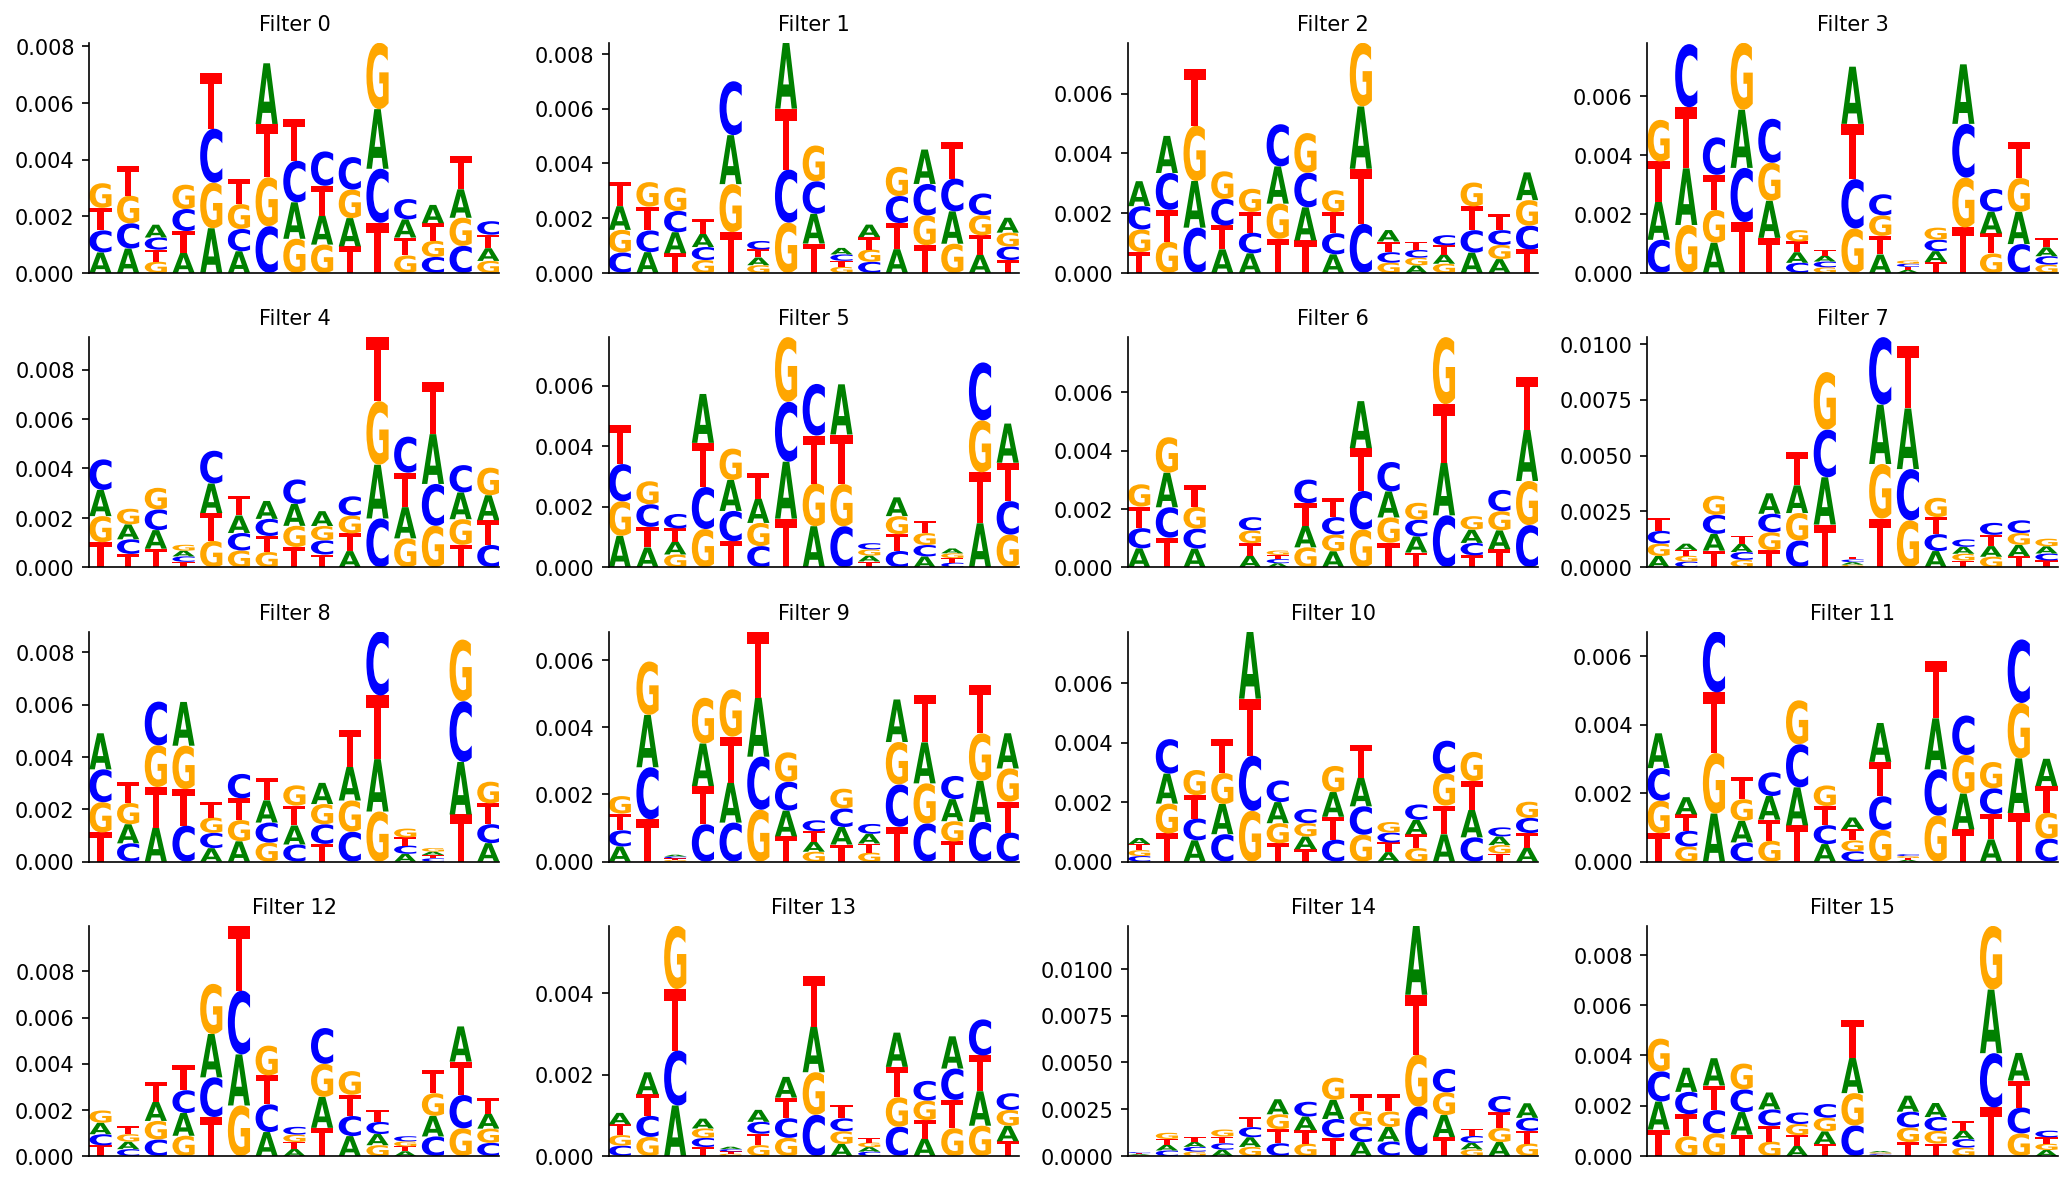

In [11]:
filter_plot_path = os.path.join(plot_dir, "shallow_cnn_filters.png")
filter_meme_path = os.path.join(plot_dir, "shallow_cnn_filters.meme")

print("Extracting first-layer convolutional filter weights as PWMs...")
pwms = src.interpret.cnn_interpretability.extract_filters_to_pwms(trained_cnn_models["shallow_cnn"])
print(f"Extracted {len(pwms)} PWMs. Kernel size (width): {pwms[0].shape[1]}")

print("Plotting filter visualization grid...")
src.interpret.cnn_interpretability.plot_filters_grid(pwms, filter_plot_path, max_display=16)

print("Saving PWMs to MEME format for Tomtom motif scanning...")
src.interpret.cnn_interpretability.save_pwms_to_meme(pwms, filter_meme_path)

# Display the filter grid
try:
    from IPython.display import Image, display
    display(Image(filename=filter_plot_path))
except Exception as e:
    print(f"Notice: IPython display failed: {e}")

## 11. Nucleotide-Resolution Attributions (Saliency & Integrated Gradients)

Compute per-nucleotide attribution scores for high-confidence true-positive predictions from the ShallowCNN. Visualize the attribution landscape as nucleotide-level logos.

High-confidence true positives: 183 sequences (prob >= 0.85)
Saved sequence attribution logo plot to /kaggle/working/plots/TP_1_prob0.907_saliency.png
Saved sequence attribution logo plot to /kaggle/working/plots/TP_1_prob0.907_integrated_gradients.png

Sequence TP_1_prob0.907:
Saliency Map:


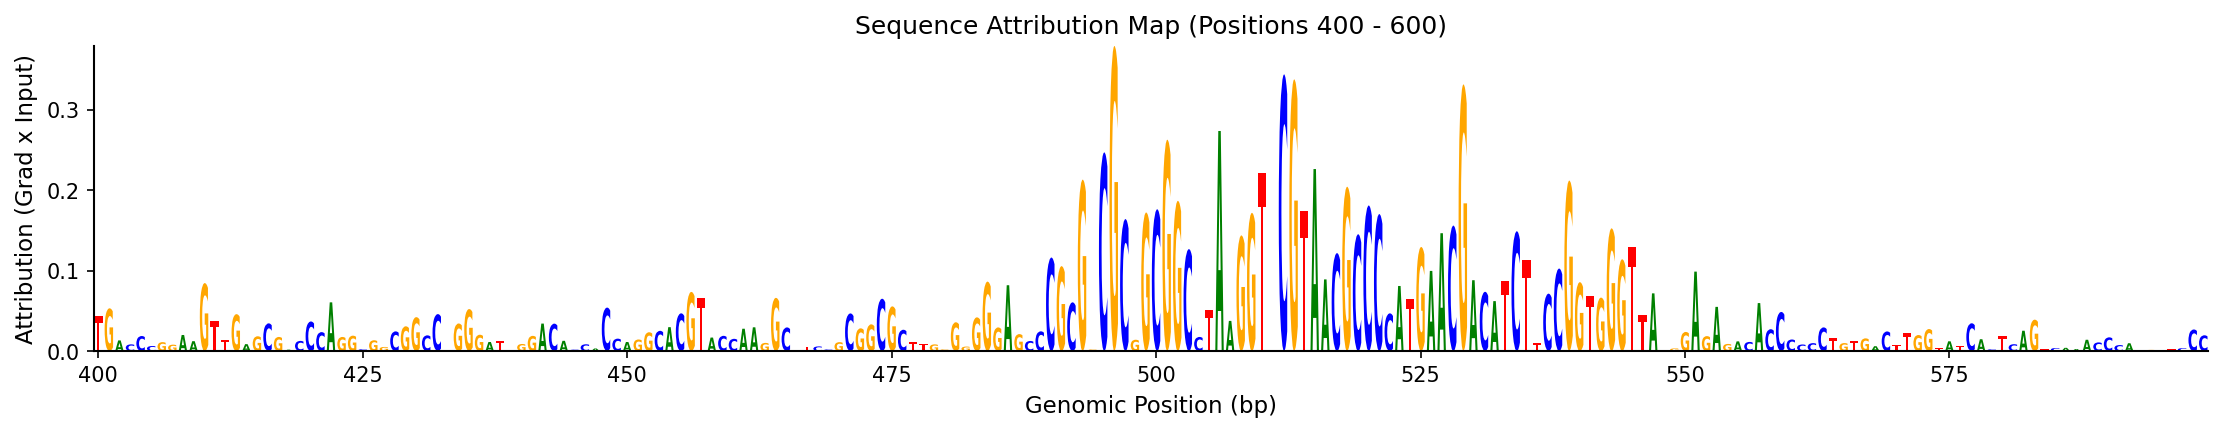

Integrated Gradients:


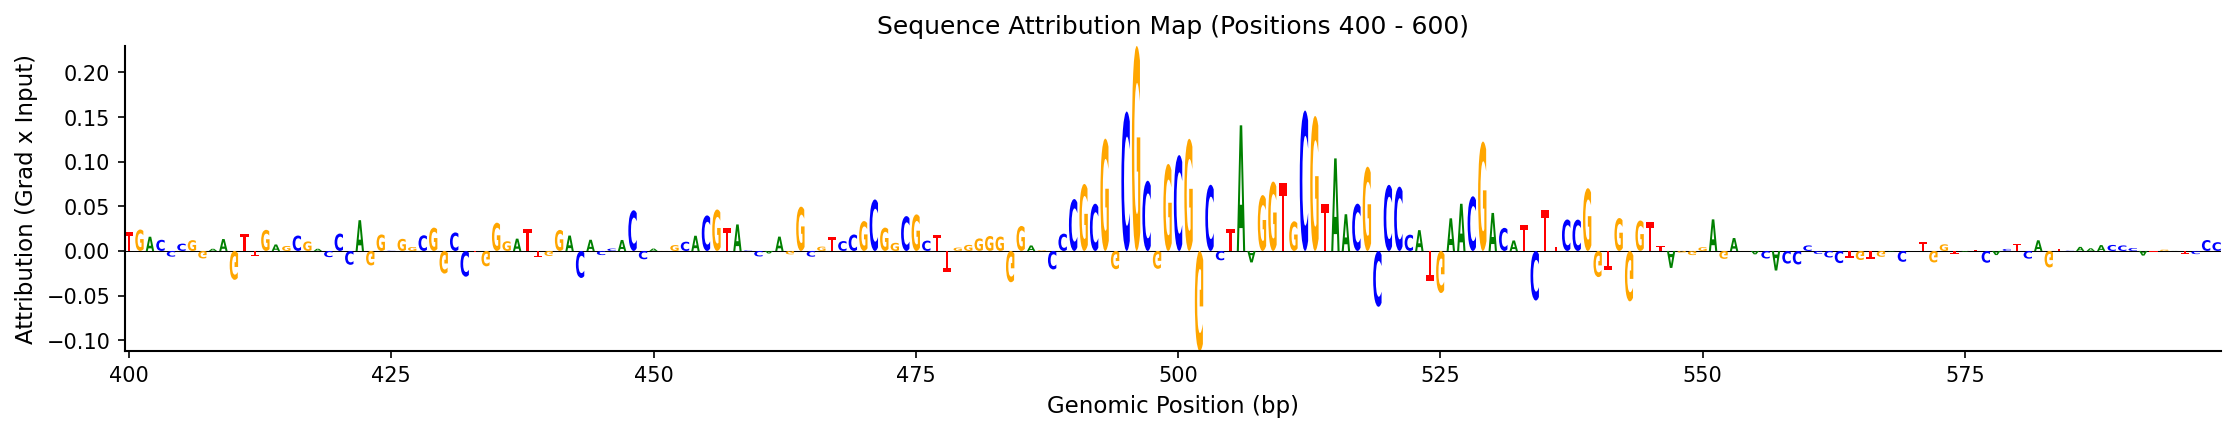

Saved sequence attribution logo plot to /kaggle/working/plots/TP_2_prob0.919_saliency.png
Saved sequence attribution logo plot to /kaggle/working/plots/TP_2_prob0.919_integrated_gradients.png

Sequence TP_2_prob0.919:
Saliency Map:


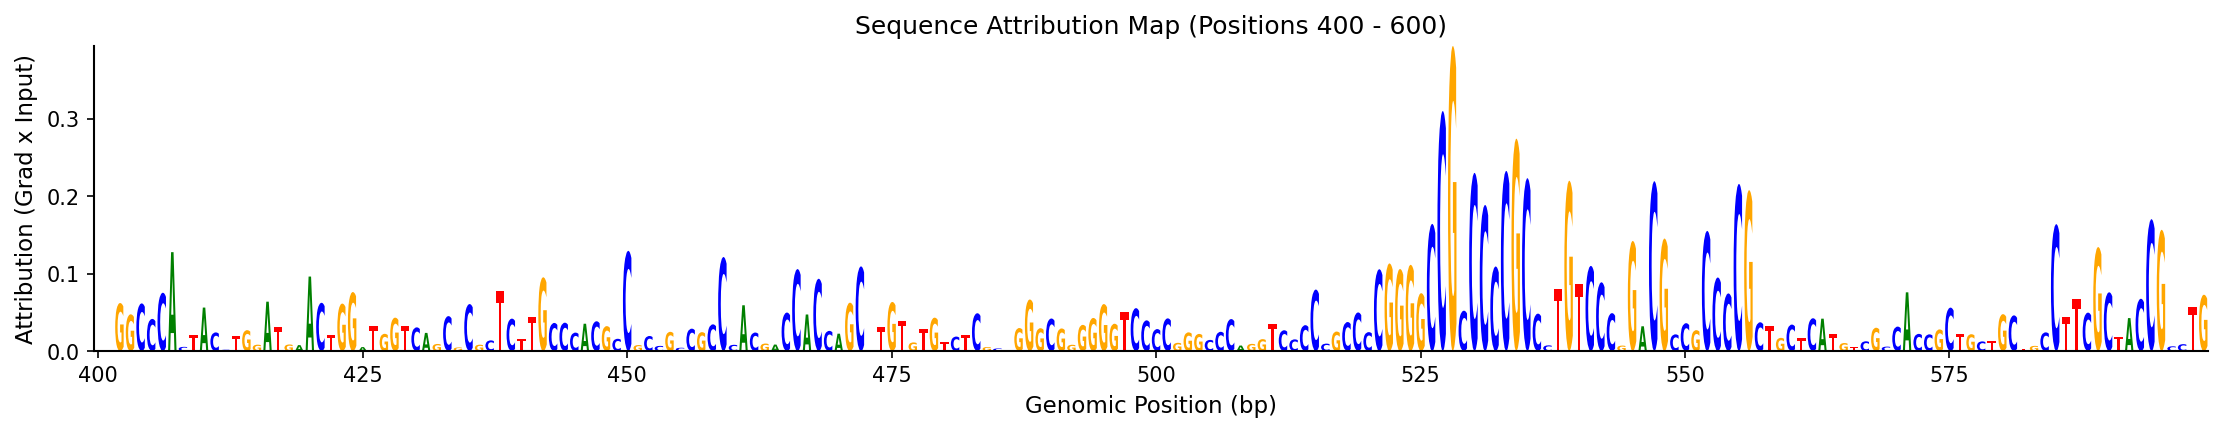

Integrated Gradients:


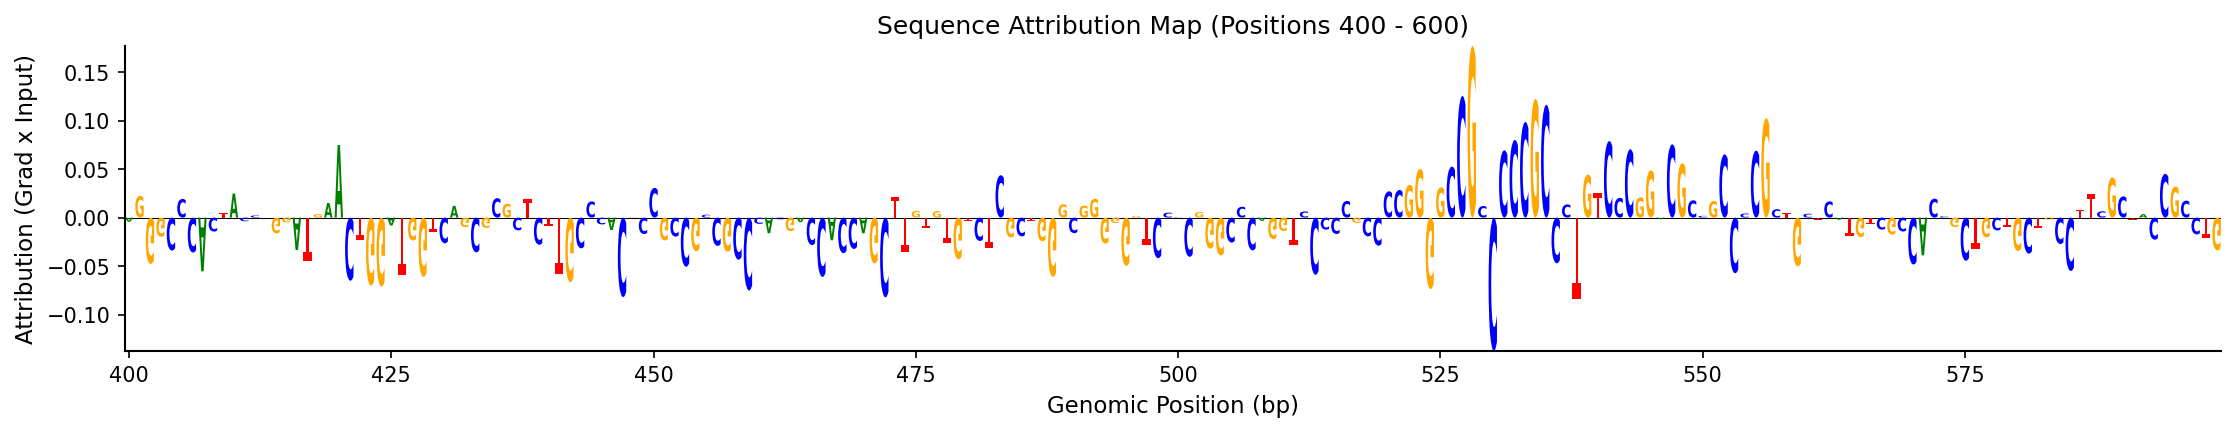

Saved sequence attribution logo plot to /kaggle/working/plots/TP_3_prob0.967_saliency.png
Saved sequence attribution logo plot to /kaggle/working/plots/TP_3_prob0.967_integrated_gradients.png

Sequence TP_3_prob0.967:
Saliency Map:


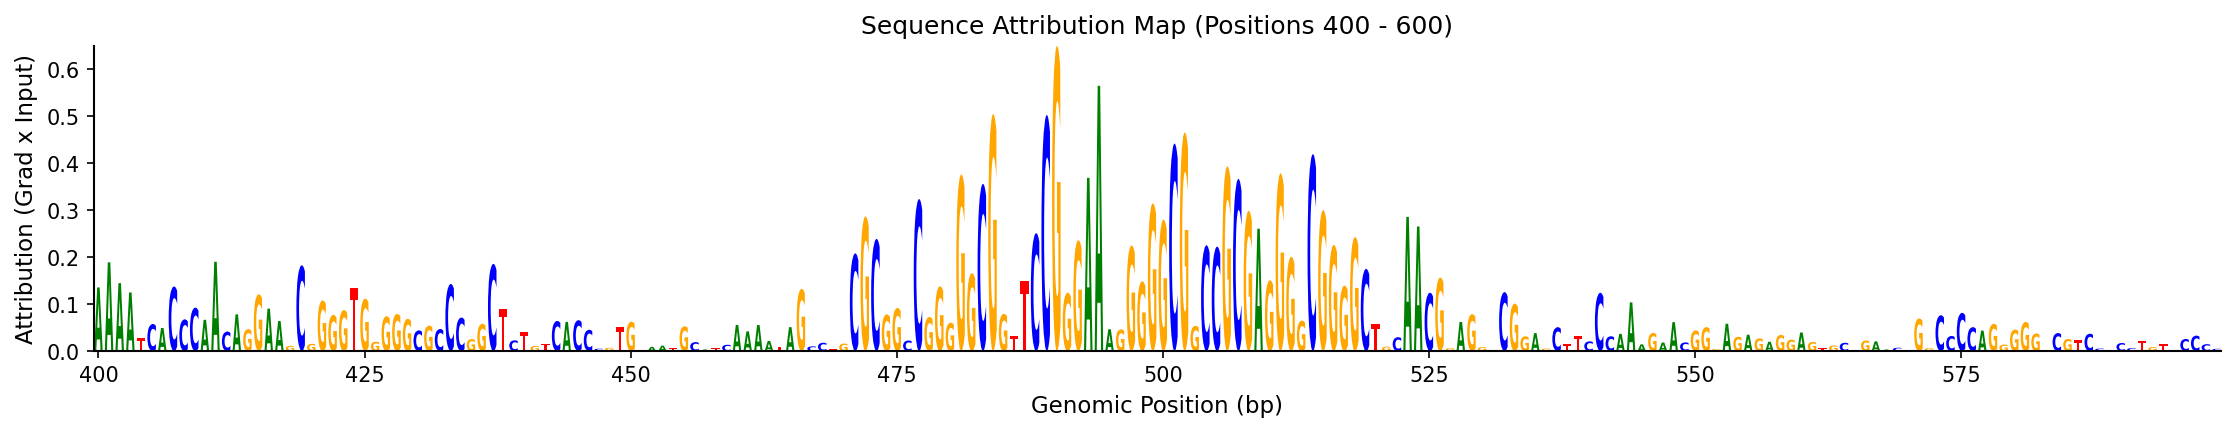

Integrated Gradients:


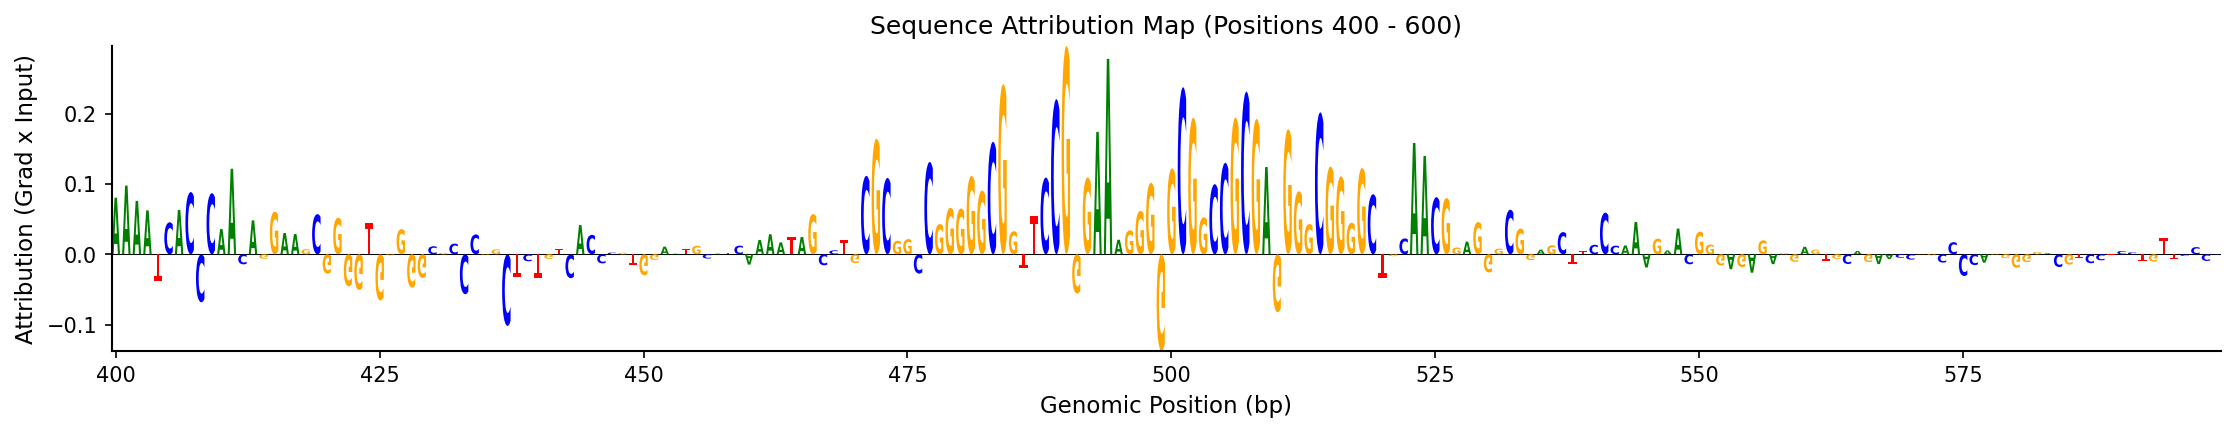

Saved sequence attribution logo plot to /kaggle/working/plots/TP_4_prob0.930_saliency.png
Saved sequence attribution logo plot to /kaggle/working/plots/TP_4_prob0.930_integrated_gradients.png

Sequence TP_4_prob0.930:
Saliency Map:


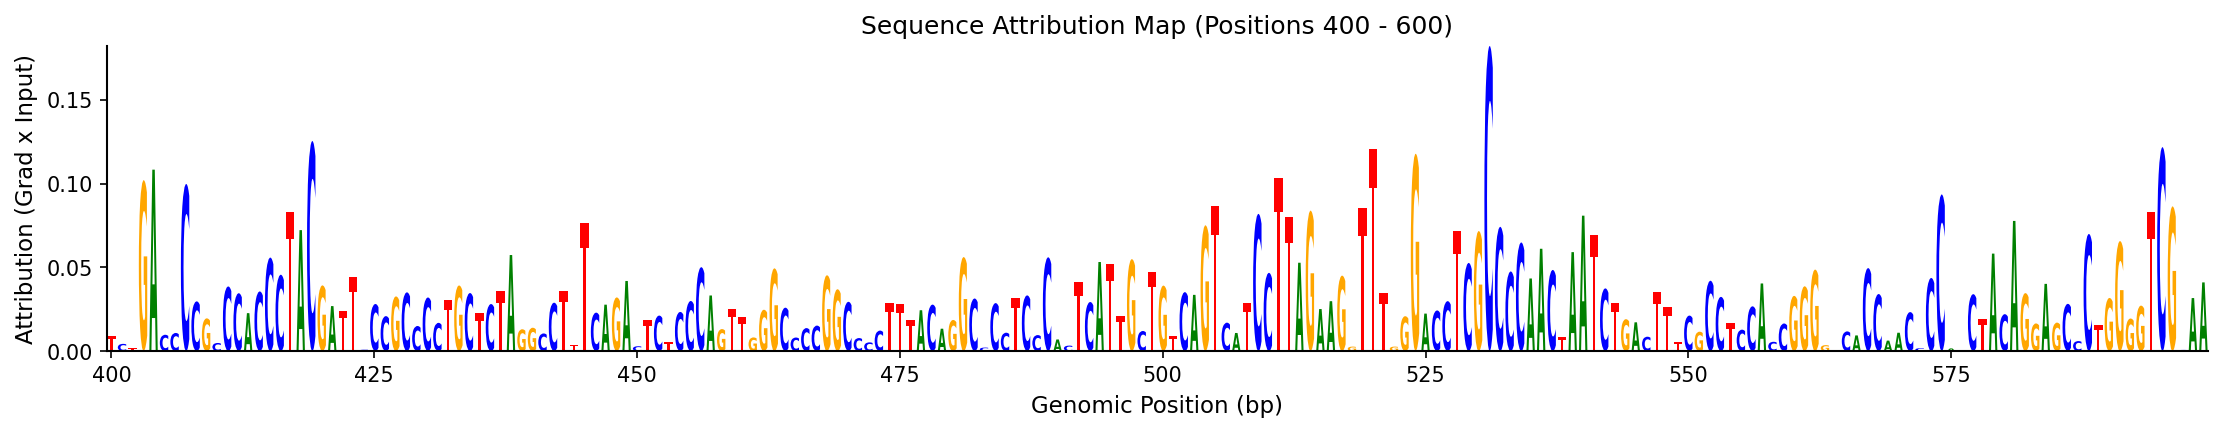

Integrated Gradients:


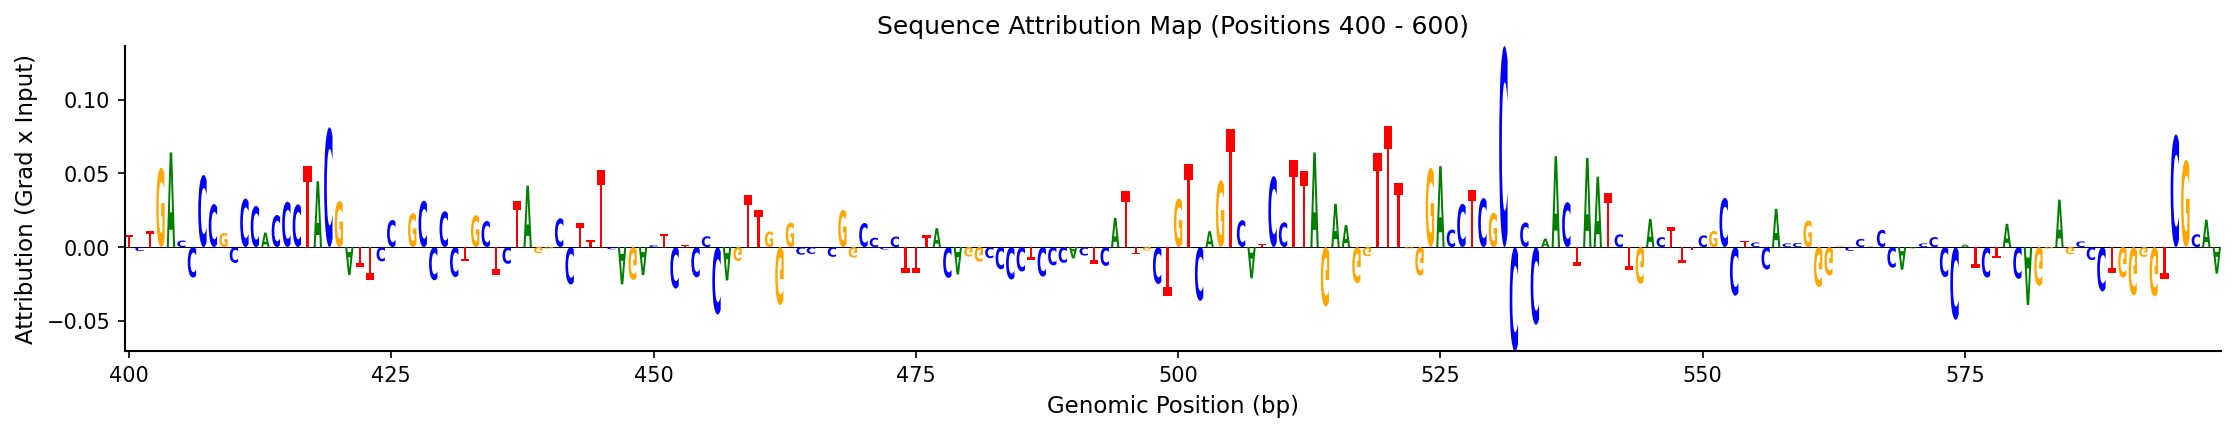

Saved sequence attribution logo plot to /kaggle/working/plots/TP_5_prob0.958_saliency.png
Saved sequence attribution logo plot to /kaggle/working/plots/TP_5_prob0.958_integrated_gradients.png

Sequence TP_5_prob0.958:
Saliency Map:


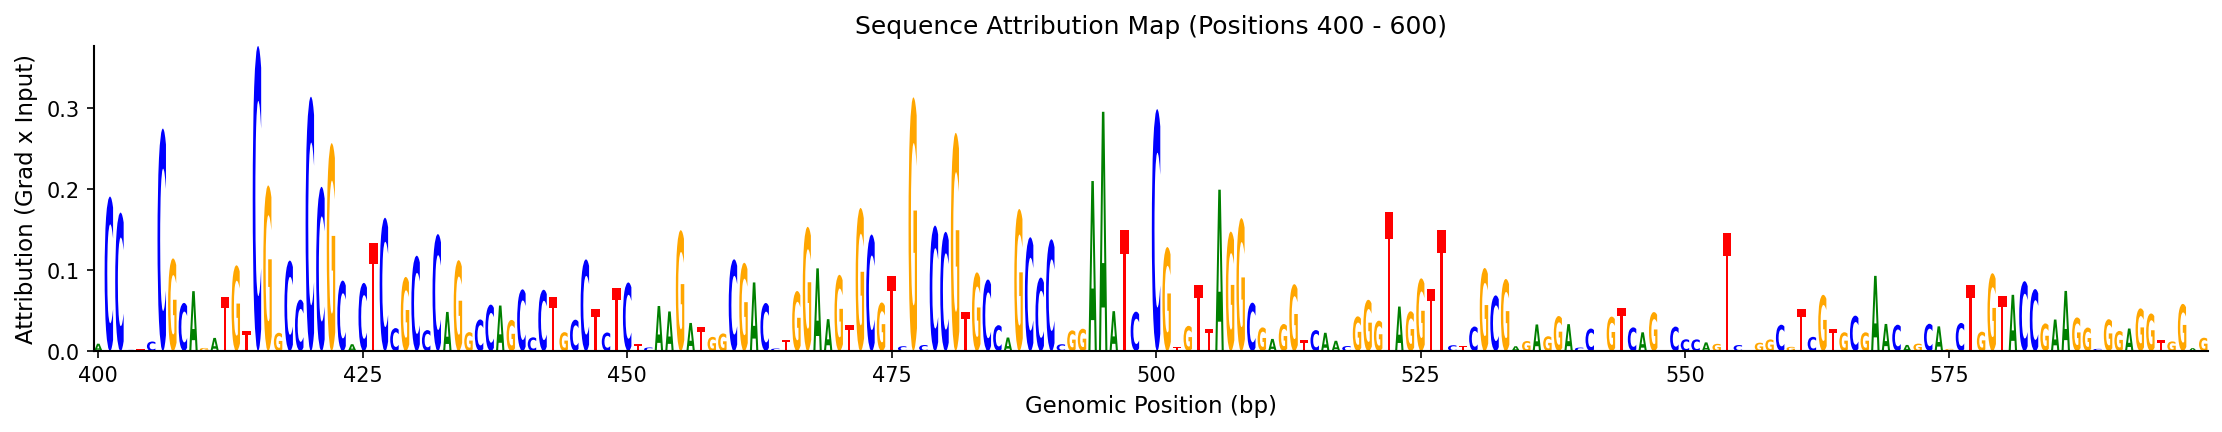

Integrated Gradients:


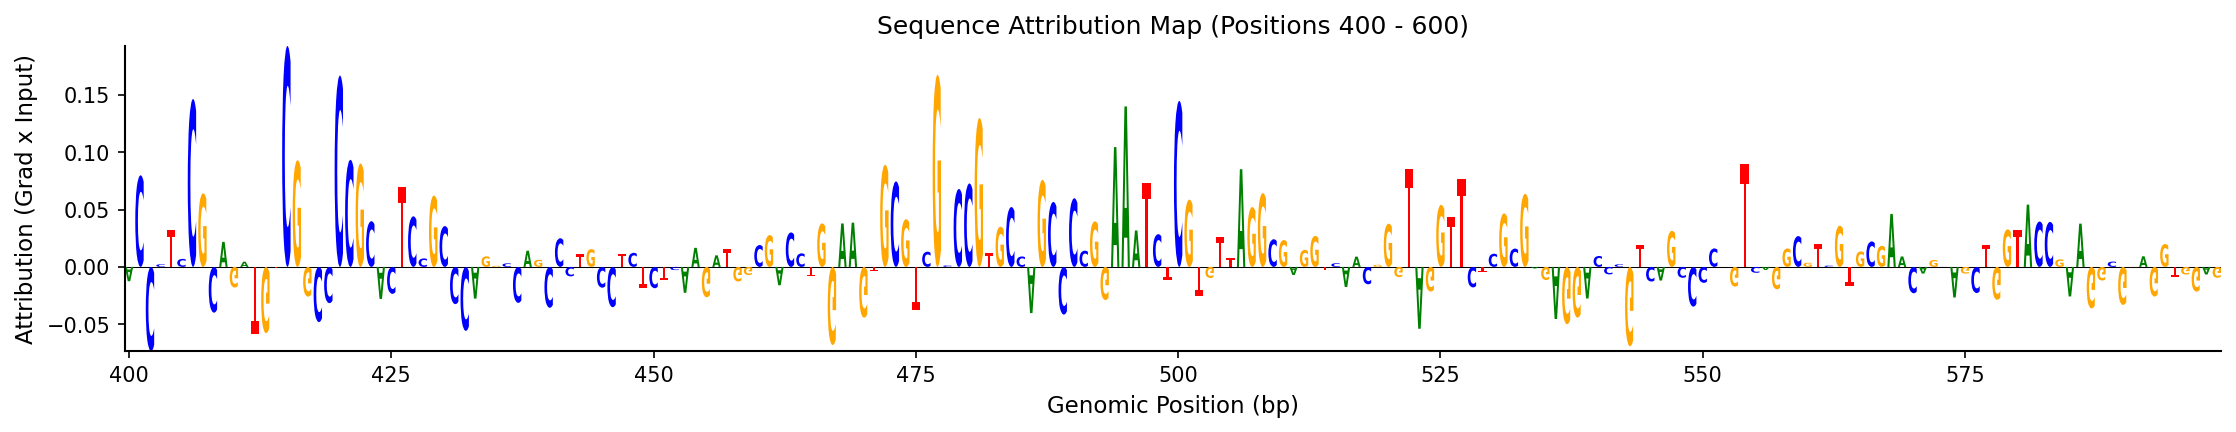

In [12]:
import torch

# Identify high-confidence true positives from test set
y_prob_cnn = trained_cnn_models["shallow_cnn"].predict_proba(df_test['sequence'].values)
true_pos_mask = (y_test == 1) & (y_prob_cnn >= 0.85)
tp_indices = np.where(true_pos_mask)[0]

print(f"High-confidence true positives: {len(tp_indices)} sequences (prob >= 0.85)")

# Select up to 5 representative sequences
n_explain = min(5, len(tp_indices))
select_idx = tp_indices[:n_explain]

test_dataset = src.data.dataset.GenomicDataset(df_test)

for i, idx in enumerate(select_idx):
    seq_name = f"TP_{i+1}_prob{y_prob_cnn[idx]:.3f}"
    x_tensor, _ = test_dataset[idx]
    input_batch = x_tensor.unsqueeze(0) # Shape: (1, 4, 1000)
    
    # Saliency Map
    saliency_attr = src.interpret.cnn_interpretability.compute_attribution(
        trained_cnn_models["shallow_cnn"], input_batch, method='saliency'
    )
    
    # Integrated Gradients
    ig_attr = src.interpret.cnn_interpretability.compute_attribution(
        trained_cnn_models["shallow_cnn"], input_batch, method='integrated_gradients'
    )
    
    # Save plots for center 200 bp window
    sal_plot_path = os.path.join(plot_dir, f"{seq_name}_saliency.png")
    ig_plot_path = os.path.join(plot_dir, f"{seq_name}_integrated_gradients.png")
    
    src.interpret.cnn_interpretability.plot_sequence_attribution(
        x_tensor.numpy(), saliency_attr[0], sal_plot_path, start_pos=400, end_pos=600
    )
    src.interpret.cnn_interpretability.plot_sequence_attribution(
        x_tensor.numpy(), ig_attr[0], ig_plot_path, start_pos=400, end_pos=600
    )
    
    print(f"\nSequence {seq_name}:")
    try:
        from IPython.display import Image, display
        print("Saliency Map:")
        display(Image(filename=sal_plot_path))
        print("Integrated Gradients:")
        display(Image(filename=ig_plot_path))
    except Exception as e:
        print(f"Notice: IPython display failed: {e}")

## 12. Summary

A summary of the Phase 2 results is printed below, including the model comparison table and key interpretability findings.

In [14]:
print("\n" + "="*70)
print("PHASE 2 SUMMARY")
print("="*70)
print("\nFull Model Comparison (Phase 1 Classical Baselines + Phase 2 CNNs):")
print(df_all_metrics.to_string(index=False))

best_model_name = df_all_metrics.loc[df_all_metrics['AUROC'].idxmax(), 'Model']
best_auroc = df_all_metrics['AUROC'].max()
print(f"\nBest performing model: {best_model_name} (AUROC: {best_auroc:.4f})")

print(f"\nCNN Filter Analysis:")
print(f"  Extracted {len(pwms)} first-layer filters from ShallowCNN")
print(f"  Kernel width: {pwms[0].shape[1]} bp")
print(f"  MEME file saved to: {filter_meme_path}")
print(f"  (Upload to https://meme-suite.org/meme/tools/tomtom to find JASPAR motif matches)")

print(f"\nAttribution Analysis:")
print(f"  Saliency maps and Integrated Gradients computed for {n_explain} high-confidence true positives")
print(f"  Plots saved to: {plot_dir}")

print("\n" + "="*70)
print("Phase 2 complete. Ready for Decision Gate 2→3 evaluation.")
print("="*70)


PHASE 2 SUMMARY

Full Model Comparison (Phase 1 Classical Baselines + Phase 2 CNNs):
              Model    AUROC    AUPRC  F1-Score  Log Loss  Train Time (s)
LOGISTIC REGRESSION 0.778075 0.730084  0.731771  0.659684        0.042915
      RANDOM FOREST 0.863487 0.872212  0.791123  0.485374        3.292949
            XGBOOST 0.894498 0.893204  0.807643  0.579535        1.098330
        SHALLOW CNN 0.868302 0.877019  0.796855  0.452174       20.439309
           DEEP CNN 0.838489 0.837421  0.761421  0.500019       12.456836

Best performing model: XGBOOST (AUROC: 0.8945)

CNN Filter Analysis:
  Extracted 64 first-layer filters from ShallowCNN
  Kernel width: 15 bp
  MEME file saved to: /kaggle/working/plots/shallow_cnn_filters.meme
  (Upload to https://meme-suite.org/meme/tools/tomtom to find JASPAR motif matches)

Attribution Analysis:
  Saliency maps and Integrated Gradients computed for 5 high-confidence true positives
  Plots saved to: /kaggle/working/plots

Phase 2 complete. Ready

## 13. Benchmarking the AttentionCNN (Hybrid Architecture)

As a final benchmark for Phase 2, we will evaluate the **`AttentionCNN`**. 

This model represents a powerful bridge between classical convolutions and modern foundation models. It first passes the raw DNA sequences through a 1D convolutional layer to extract local spatial motifs (like SP1 and CTCF) and then feeds those extracted feature maps into a **multi-head self-attention** layer. This allows the network to learn long-range genomic interactions and dependencies before making its final classification.

We will benchmark its AUROC and Log Loss below to see if the addition of the Attention mechanism improves upon the standard Deep CNN baseline.


In [16]:
from src.models.cnn import AttentionCNN
from src.models.train_nn import PyTorchModelWrapper
from sklearn.metrics import roc_auc_score, log_loss

# 1. Initialize the Attention Model
attention_model = PyTorchModelWrapper(
    model_class=AttentionCNN,
    epochs=15,          
    batch_size=64,
    lr=0.001,
    val_split=0.15 # Automatically splits 15% for validation!
)

# 2. Train the model using the raw sequences from df_train
print("Training AttentionCNN...")
attention_model.fit(df_train['sequence'].values, y_train)

# 3. Predict on the test set sequences
y_pred_proba = attention_model.predict_proba(df_test['sequence'].values)

# 4. Print the official Benchmark Scores!
auroc = roc_auc_score(y_test, y_pred_proba)
loss = log_loss(y_test, y_pred_proba)

print(f"AttentionCNN Final AUROC: {auroc:.4f}")
print(f"AttentionCNN Final Log Loss: {loss:.4f}")


Training AttentionCNN...
Training on device: cuda
Epoch 01/15 | Train Loss: 0.7110 | Val Loss: 0.6912 | Val Acc: 0.4907
Epoch 02/15 | Train Loss: 0.6878 | Val Loss: 0.6669 | Val Acc: 0.6480
Epoch 03/15 | Train Loss: 0.6568 | Val Loss: 0.6113 | Val Acc: 0.6977
Epoch 04/15 | Train Loss: 0.6163 | Val Loss: 0.5862 | Val Acc: 0.7039
Epoch 05/15 | Train Loss: 0.5621 | Val Loss: 0.5640 | Val Acc: 0.7143
Epoch 06/15 | Train Loss: 0.5165 | Val Loss: 0.5813 | Val Acc: 0.7060
Epoch 07/15 | Train Loss: 0.4585 | Val Loss: 0.4887 | Val Acc: 0.7660
Epoch 08/15 | Train Loss: 0.4119 | Val Loss: 0.5977 | Val Acc: 0.7184
Epoch 09/15 | Train Loss: 0.3805 | Val Loss: 0.5822 | Val Acc: 0.7060
Epoch 10/15 | Train Loss: 0.3340 | Val Loss: 0.5498 | Val Acc: 0.7578
Epoch 11/15 | Train Loss: 0.2706 | Val Loss: 0.5380 | Val Acc: 0.7805
Epoch 12/15 | Train Loss: 0.2297 | Val Loss: 0.5924 | Val Acc: 0.7785
Early stopping triggered at epoch 12.
Loaded best validation model (Loss: 0.4887).
AttentionCNN Final AUROC: 0